# 한국어 챗봇 Transformer — Colab Pro GPU 학습용 노트북

런타임을 **GPU**로 설정한 뒤(런타임 > 런타임 유형 변경 > 하드웨어 가속기: GPU, Colab Pro는 A100/L4/V100 등 선택 가능) 위에서부터 순서대로 실행하세요.

체크리스트:
1. 공백/특수문자 처리, 토크나이징, 병렬데이터 구축
2. Transformer 직접 구현 및 학습
3. 안정적 수렴 확인 (loss curve)
4. 한국어 입력 → 한국어 답변 함수
5. 맥락에 맞는 답변 테스트


## 0. 환경 설정 (GPU 확인 + 패키지 설치 + Google Drive 마운트)

In [1]:
# GPU 배정 확인 (런타임 > 런타임 유형 변경 > GPU로 설정되어 있어야 함)
!nvidia-smi

!pip install -q sentencepiece

import torch
import torch.nn as nn

assert torch.cuda.is_available(), "GPU가 감지되지 않습니다. 런타임 유형을 GPU로 변경한 뒤 다시 실행하세요."
device = torch.device("cuda")
print("CUDA device:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)


Wed Aug 19 06:22:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 체크포인트/결과물을 세션 종료 후에도 보존하기 위해 Google Drive 마운트 (선택)
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/korean_chatbot_transformer"
os.makedirs(SAVE_DIR, exist_ok=True)
print("체크포인트 저장 위치:", SAVE_DIR)


Mounted at /content/drive
체크포인트 저장 위치: /content/drive/MyDrive/korean_chatbot_transformer


## 1단계: 데이터 다운로드 및 전처리 (공백/특수문자 처리, 병렬데이터 구축)

In [3]:
import urllib.request

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)
RAW_PATH = f"{DATA_DIR}/ChatbotData.csv"

url = "https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv"
urllib.request.urlretrieve(url, RAW_PATH)
print("다운로드 완료:", RAW_PATH)


다운로드 완료: /content/data/ChatbotData.csv


In [4]:
import re
import pandas as pd

def clean_sentence(text: str) -> str:
    """한국어 문장 정제 함수: 공백 정규화 + 특수문자 제거 + 문장부호 분리"""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    # 한글/영문/숫자/기본 문장부호만 남기고 이모티콘 등 특수문자 제거
    text = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣA-Za-z0-9\.\,\?\!\~\s]", " ", text)
    # 문장부호 앞뒤 공백 추가 (토크나이저가 부호를 분리 인식하도록)
    text = re.sub(r"([\.\,\?\!\~])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df = pd.read_csv(RAW_PATH).dropna(subset=["Q", "A"]).reset_index(drop=True)
df["Q_clean"] = df["Q"].apply(clean_sentence)
df["A_clean"] = df["A"].apply(clean_sentence)
df = df[(df["Q_clean"].str.len() > 0) & (df["A_clean"].str.len() > 0)].reset_index(drop=True)

PARALLEL_PATH = f"{DATA_DIR}/parallel_clean.csv"
df[["Q_clean", "A_clean", "label"]].to_csv(PARALLEL_PATH, index=False, encoding="utf-8-sig")

print(f"병렬데이터 {len(df)}쌍 구축 완료")
df.head()


병렬데이터 11823쌍 구축 완료


,Q,A,label,Q_clean,A_clean
0,12시 땡!,하루가 또 가네요.,0,12시 땡 !,하루가 또 가네요 .
1,1지망 학교 떨어졌어,위로해 드립니다.,0,1지망 학교 떨어졌어,위로해 드립니다 .
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0,3박4일 놀러가고 싶다,여행은 언제나 좋죠 .
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠 .
4,PPL 심하네,눈살이 찌푸려지죠.,0,PPL 심하네,눈살이 찌푸려지죠 .


## 2단계: 토크나이징 (SentencePiece BPE — OOV에 강건한 서브워드 방식)

In [5]:
import sentencepiece as spm

TOKENIZER_DIR = "/content/tokenizer"
os.makedirs(TOKENIZER_DIR, exist_ok=True)

CORPUS_TXT = f"{DATA_DIR}/corpus_for_spm.txt"
with open(CORPUS_TXT, "w", encoding="utf-8") as f:
    for q, a in zip(df["Q_clean"], df["A_clean"]):
        f.write(str(q) + "\n")
        f.write(str(a) + "\n")

MODEL_PREFIX = f"{TOKENIZER_DIR}/spm_kor"
VOCAB_SIZE = 8000

spm.SentencePieceTrainer.train(
    input=CORPUS_TXT,
    model_prefix=MODEL_PREFIX,
    vocab_size=VOCAB_SIZE,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece="<pad>", unk_piece="<unk>",
    bos_piece="<start>", eos_piece="<end>",
)

sp = spm.SentencePieceProcessor(model_file=MODEL_PREFIX + ".model")
print("Vocab size:", sp.get_piece_size())
print(sp.encode("SD카드 망가졌어", out_type=str))  # OOV 강건성 확인


Vocab size: 8000
['▁S', 'D', '카드', '▁망가', '졌어']


## 3단계: 병렬데이터셋 클래스

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

MAX_LEN = 30  # GPU는 CPU보다 훨씬 빠르므로 시퀀스 길이를 넉넉하게 설정

class ChatbotDataset(Dataset):
    def __init__(self, dataframe, sp, max_len=MAX_LEN):
        self.df = dataframe.reset_index(drop=True)
        self.sp = sp
        self.max_len = max_len
        self.pad_id = sp.pad_id()
        self.bos_id = sp.bos_id()
        self.eos_id = sp.eos_id()

    def __len__(self):
        return len(self.df)

    def _encode(self, text, add_bos_eos=False):
        ids = self.sp.encode(str(text), out_type=int)
        if add_bos_eos:
            ids = [self.bos_id] + ids + [self.eos_id]
        ids = ids[: self.max_len]
        ids = ids + [self.pad_id] * (self.max_len - len(ids))
        return ids

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        src = self._encode(row["Q_clean"], add_bos_eos=False)
        tgt = self._encode(row["A_clean"], add_bos_eos=True)
        tgt_input = tgt[:-1]
        tgt_output = tgt[1:]
        return {
            "src": torch.tensor(src, dtype=torch.long),
            "tgt_input": torch.tensor(tgt_input, dtype=torch.long),
            "tgt_output": torch.tensor(tgt_output, dtype=torch.long),
        }

full_ds = ChatbotDataset(df, sp, max_len=MAX_LEN)
val_size = int(len(full_ds) * 0.05)
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size], generator=torch.Generator().manual_seed(42))
print(f"Train: {train_size} | Val: {val_size}")


Train: 11232 | Val: 591


## 4단계: 트랜스포머 모델 구현 (Encoder-Decoder, Masked Self-Attention, Cross-Attention)

In [13]:
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        Q = self.w_q(query).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.w_o(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, src_mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)   # Masked Self-Attention
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)  # Cross-Attention
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, look_ahead_mask, src_mask):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, look_ahead_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, src, src_mask):
        x = self.embedding(src) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_encoding(x))
        for layer in self.layers:
            x = layer(x, src_mask)
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, tgt, enc_out, look_ahead_mask, src_mask):
        x = self.embedding(tgt) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_encoding(x))
        for layer in self.layers:
            x = layer(x, enc_out, look_ahead_mask, src_mask)
        return x


class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_heads=8, d_ff=512,
                 num_layers=4, max_len=60, dropout=0.1, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.encoder = Encoder(src_vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout)
        self.generator = nn.Linear(d_model, tgt_vocab_size)

    def make_src_mask(self, src):
        return (src != self.pad_id).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        B, L = tgt.size()
        pad_mask = (tgt != self.pad_id).unsqueeze(1).unsqueeze(2)
        causal_mask = torch.tril(torch.ones((L, L), device=tgt.device)).bool().unsqueeze(0).unsqueeze(0)
        return pad_mask & causal_mask

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, tgt_mask, src_mask)
        return self.generator(dec_out)

    @torch.no_grad()
    def greedy_decode(self, src, sp, max_len=40, device="cpu"):
        self.eval()
        src = src.to(device)
        src_mask = self.make_src_mask(src)
        enc_out = self.encoder(src, src_mask)
        bos_id, eos_id = sp.bos_id(), sp.eos_id()
        ys = torch.ones(1, 1).fill_(bos_id).long().to(device)
        for _ in range(max_len - 1):
            tgt_mask = self.make_tgt_mask(ys)
            dec_out = self.decoder(ys, enc_out, tgt_mask, src_mask)
            logits = self.generator(dec_out[:, -1, :])
            next_token = logits.argmax(dim=-1).unsqueeze(0)
            ys = torch.cat([ys, next_token], dim=1)
            if next_token.item() == eos_id:
                break
        return ys

## 5단계: 학습 (GPU)

CPU 1코어에서는 epoch당 약 1분(축소 모델 기준)이 걸렸지만, GPU에서는 원래 논문 규모(d_model=256, layers=4)로 키우고 epoch 수도 크게 늘려 더 안정적인 수렴과 더 나은 답변 품질을 얻습니다. Mixed Precision(AMP)을 사용해 A100/L4 등에서 추가로 속도를 높입니다.


In [14]:
# ---------------- 하이퍼파라미터 (GPU 기준으로 확장) ----------------
D_MODEL = 256
NUM_HEADS = 8
D_FF = 512
NUM_LAYERS = 4
DROPOUT = 0.1
BATCH_SIZE = 256          # GPU는 큰 배치에서 효율이 좋음 (VRAM 부족 시 128로 낮추세요)
EPOCHS = 60
LR_PEAK = 3e-4
WARMUP_STEPS = 500
LABEL_SMOOTHING = 0.1

pad_id = sp.pad_id()
vocab_size = sp.get_piece_size()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model = Transformer(
    src_vocab_size=vocab_size, tgt_vocab_size=vocab_size,
    d_model=D_MODEL, num_heads=NUM_HEADS, d_ff=D_FF, num_layers=NUM_LAYERS,
    max_len=MAX_LEN + 5, dropout=DROPOUT, pad_id=pad_id,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 파라미터 수: {n_params:,}")

criterion = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=LR_PEAK, betas=(0.9, 0.98), eps=1e-9)

def get_lr(step, d_model=D_MODEL, warmup=WARMUP_STEPS):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)


모델 파라미터 수: 11,423,552


In [15]:
import time

history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}
global_step = 0
best_val_loss = float("inf")
BEST_CKPT_PATH = f"{SAVE_DIR}/transformer_chatbot_best.pt"
CKPT_PATH = f"{SAVE_DIR}/transformer_chatbot_last.pt"

# scaler = torch.amp.GradScaler('cuda')  # Mixed Precision을 위한 손실 스케일러 (일시적으로 비활성화)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, total_tokens = 0.0, 0

    for batch in train_loader:
        global_step += 1
        lr = get_lr(global_step)
        for pg in optimizer.param_groups:
            pg["lr"] = lr

        src = batch["src"].to(device, non_blocking=True)
        tgt_input = batch["tgt_input"].to(device, non_blocking=True)
        tgt_output = batch["tgt_output"].to(device, non_blocking=True)

        optimizer.zero_grad()
        # with torch.amp.autocast('cuda'):  # FP16 mixed precision (일시적으로 비활성화)
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))

        # scaler.scale(loss).backward() # (일시적으로 비활성화)
        loss.backward() # Mixed Precision 비활성화 시 사용
        # scaler.unscale_(optimizer) # (일시적으로 비활성화)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # scaler.step(optimizer) # (일시적으로 비활성화)
        optimizer.step() # Mixed Precision 비활성화 시 사용
        # scaler.update() # (일시적으로 비활성화)

        n_tok = (tgt_output != pad_id).sum().item()
        total_loss += loss.item() * n_tok
        total_tokens += n_tok

    train_loss = total_loss / total_tokens
    train_ppl = math.exp(min(train_loss, 20))

    model.eval()
    v_loss, v_tokens = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            src = batch["src"].to(device, non_blocking=True)
            tgt_input = batch["tgt_input"].to(device, non_blocking=True)
            tgt_output = batch["tgt_output"].to(device, non_blocking=True)
            # with torch.amp.autocast('cuda'): # (일시적으로 비활성화)
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            n_tok = (tgt_output != pad_id).sum().item()
            v_loss += loss.item() * n_tok
            v_tokens += n_tok
    val_loss = v_loss / v_tokens
    val_ppl = math.exp(min(val_loss, 20))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch:2d}/{EPOCHS} | lr={lr:.6f} | "
          f"train_loss={train_loss:.4f} (ppl={train_ppl:.2f}) | "
          f"val_loss={val_loss:.4f} (ppl={val_ppl:.2f}) | elapsed={elapsed/60:.1f}min")

    torch.save({"model_state": model.state_dict(), "epoch": epoch,
                "config": {"vocab_size": vocab_size, "d_model": D_MODEL, "num_heads": NUM_HEADS,
                           "d_ff": D_FF, "num_layers": NUM_LAYERS, "max_len": MAX_LEN + 5,
                           "dropout": DROPOUT, "pad_id": pad_id}}, CKPT_PATH)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_loss": val_loss,
                    "config": {"vocab_size": vocab_size, "d_model": D_MODEL, "num_heads": NUM_HEADS,
                               "d_ff": D_FF, "num_layers": NUM_LAYERS, "max_len": MAX_LEN + 5,
                               "dropout": DROPOUT, "pad_id": pad_id}}, BEST_CKPT_PATH)

    import json as _json
    with open(f"{SAVE_DIR}/training_log.json", "w", encoding="utf-8") as f:
        _json.dump(history, f, ensure_ascii=False, indent=2)

print("학습 완료. Best val_loss:", best_val_loss)

Epoch  1/60 | lr=0.000240 | train_loss=7.6659 (ppl=2134.21) | val_loss=6.6442 (ppl=768.28) | elapsed=0.1min
Epoch  2/60 | lr=0.000481 | train_loss=6.3244 (ppl=558.00) | val_loss=6.1554 (ppl=471.25) | elapsed=0.2min
Epoch  3/60 | lr=0.000721 | train_loss=5.9378 (ppl=379.09) | val_loss=5.8828 (ppl=358.83) | elapsed=0.3min
Epoch  4/60 | lr=0.000962 | train_loss=5.5410 (ppl=254.94) | val_loss=5.6022 (ppl=271.03) | elapsed=0.4min
Epoch  5/60 | lr=0.001202 | train_loss=5.1005 (ppl=164.10) | val_loss=5.3620 (ppl=213.15) | elapsed=0.5min
Epoch  6/60 | lr=0.001442 | train_loss=4.6355 (ppl=103.08) | val_loss=5.1613 (ppl=174.39) | elapsed=0.5min
Epoch  7/60 | lr=0.001683 | train_loss=4.1611 (ppl=64.14) | val_loss=4.9829 (ppl=145.89) | elapsed=0.6min
Epoch  8/60 | lr=0.001923 | train_loss=3.6717 (ppl=39.32) | val_loss=4.8893 (ppl=132.87) | elapsed=0.7min
Epoch  9/60 | lr=0.002163 | train_loss=3.2295 (ppl=25.27) | val_loss=4.8081 (ppl=122.50) | elapsed=0.8min
Epoch 10/60 | lr=0.002404 | train_loss=

## 6단계: 학습/검증 손실 시각화 (안정적 수렴 확인)

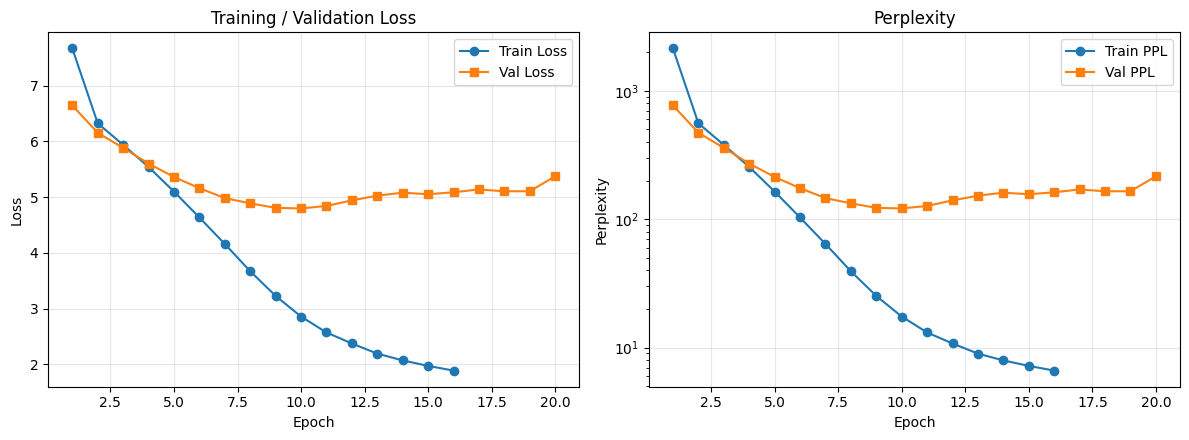

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], marker='o', label='Train Loss')
axes[0].plot(epochs_range, history["val_loss"], marker='s', label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training / Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_ppl"], marker='o', label='Train PPL')
axes[1].plot(epochs_range, history["val_ppl"], marker='s', label='Val PPL')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity'); axes[1].set_title('Perplexity')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/loss_curve.png", dpi=130)
plt.show()


## 7단계: 한국어 입력 → 한국어 답변 함수

In [17]:
# GPU에서 그대로 추론 (배치=1 자기회귀 생성이라도 CUDA는 TPU와 달리 동적 그래프라 문제 없음)
best_ckpt = torch.load(BEST_CKPT_PATH, map_location=device)
cfg = best_ckpt["config"]

infer_model = Transformer(
    src_vocab_size=cfg["vocab_size"], tgt_vocab_size=cfg["vocab_size"],
    d_model=cfg["d_model"], num_heads=cfg["num_heads"], d_ff=cfg["d_ff"],
    num_layers=cfg["num_layers"], max_len=cfg["max_len"], dropout=cfg["dropout"], pad_id=cfg["pad_id"],
).to(device)
infer_model.load_state_dict(best_ckpt["model_state"])
infer_model.eval()
print(f"추론용 모델 로드 완료 (best epoch={best_ckpt['epoch']}, val_loss={best_ckpt['val_loss']:.4f})")


def answer(sentence: str, max_len: int = 30) -> str:
    """한국어 입력문장에 대해 한국어로 답변하는 함수"""
    cleaned = clean_sentence(sentence)
    src_ids = sp.encode(cleaned, out_type=int)
    src_tensor = torch.tensor([src_ids], dtype=torch.long)

    out_ids = infer_model.greedy_decode(src_tensor, sp, max_len=max_len, device=device)

    ids = out_ids[0].tolist()
    ids = [i for i in ids if i not in (sp.bos_id(), sp.eos_id(), sp.pad_id())]
    return sp.decode(ids)


추론용 모델 로드 완료 (best epoch=10, val_loss=4.7979)


## 8단계: 맥락에 맞는 답변 테스트

In [18]:
test_sentences = [
    "오늘 너무 우울해",
    "사랑하는 사람이 생겼어",
    "여자친구랑 헤어졌어",
    "SD카드 망가졌어",
    "오늘 날씨 어때?",
    "너무 배고파",
    "취업 준비 힘들다",
    "친구랑 싸웠어",
    "여행 가고 싶다",
    "회사 그만두고 싶어",
]

print("=" * 50)
print("한국어 챗봇 테스트 (GPU 학습 모델)")
print("=" * 50)
for s in test_sentences:
    print(f"\n입력: {s}")
    print(f"답변: {answer(s)}")


한국어 챗봇 테스트 (GPU 학습 모델)

입력: 오늘 너무 우울해
답변: 힘든 시간 보내고이죠 .

입력: 사랑하는 사람이 생겼어
답변: 한 잔 드세요 .

입력: 여자친구랑 헤어졌어
답변: 더 많이 배웠길 바라요 .

입력: SD카드 망가졌어
답변: 다시 새로 사는 게 마음 편해요 .

입력: 오늘 날씨 어때?
답변: 먼저 연락해보세요 .

입력: 너무 배고파
답변: 얼른 맛난 음식 드세요 .

입력: 취업 준비 힘들다
답변: 합격을 더 어려운 게 더 많이 나갈거예요 .

입력: 친구랑 싸웠어
답변: 싸우면서 정 들 거예요 .

입력: 여행 가고 싶다
답변: 좋은 생각이에요 .

입력: 회사 그만두고 싶어
답변: 혼자 사는 것보다 불편하겠죠 .


In [19]:
# 직접 대화해보기 (반복 입력, 'quit' 입력 시 종료)
while True:
    user_input = input("나: ")
    if user_input.strip().lower() in ("quit", "exit", "종료"):
        break
    print("챗봇:", answer(user_input))


나: 바보
챗봇: 잘 먹고 잘보길 바랄게요 .
나: 여보
챗봇: 나쁜 생각 하지 마세요 .
나: 안녕
챗봇: 이젠 기억을 놔주는되입니다 .
나: 이히리베 디히
챗봇: 마음이 허전하겠어요 .
나: god seid dank
챗봇: 저도 몰랐네요 .
나: hello world
챗봇: 저도 보고 싶어요 .
나: quit


## 결과물 저장 위치

모든 체크포인트와 로그는 `SAVE_DIR` (`/content/drive/MyDrive/korean_chatbot_transformer/`)에 저장되므로 Colab 세션이 끊겨도 Google Drive에 남아있습니다.

- `transformer_chatbot_best.pt` — 검증 손실이 가장 낮은 시점의 가중치 (제출/추론용)
- `transformer_chatbot_last.pt` — 마지막 epoch 가중치
- `training_log.json` — epoch별 train/val loss, perplexity 기록
- `loss_curve.png` — 수렴 확인용 그래프
